# SteamScope：Steam 数据集概览与项目起点

本 Notebook 回答的问题是：**为什么 Steam Games Dataset 2025 适合作为“大数据处理分析”的研究项目？**

本节不会直接做复杂分析，而是先确认数据来源、文件结构、文件规模、字段类型、样本内容和读取风险，为后续的大表格处理策略、清洗、特征工程和市场分析打基础。

## 1. 环境与路径准备

首先设置项目根目录、原始数据目录、图表输出目录和后续处理数据目录。项目约定 Kaggle 数据解压后放在 `data/raw/archive/`，该目录不上传 GitHub。

In [1]:
from pathlib import Path
import csv
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

sns.set_theme(style="whitegrid", context="notebook")
plt.style.use("seaborn-v0_8-whitegrid")

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == "notebooks" else current_dir
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "archive"
FIGURES_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Python version:", sys.version.replace("\\n", " "))
print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DIR)
print("Figures directory:", FIGURES_DIR)
print("Processed data directory:", PROCESSED_DIR)

Python version: 3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]
Project root: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights
Raw data directory: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/raw/archive
Figures directory: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures
Processed data directory: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed


## 2. 数据下载方式说明

下面这段代码是给第一次配置项目时使用的。由于 Steam 数据集超过 1GB，不应该每次运行 Notebook 都重新下载，所以这里默认保持注释状态。

如果本地没有 `data/raw/archive/` 下的 4 个 CSV 文件，再手动取消注释并运行。

In [2]:
# 可选：首次下载数据时使用。默认不要运行，避免重复下载大文件。
# import kagglehub
# from pathlib import Path
# import shutil
#
# dataset_path = kagglehub.dataset_download("artermiloff/steam-games-dataset")
# target_dir = Path("data/raw/archive")
# target_dir.mkdir(parents=True, exist_ok=True)
#
# for csv_file in Path(dataset_path).glob("*.csv"):
#     shutil.copy2(csv_file, target_dir / csv_file.name)
#
# print("Dataset copied to:", target_dir.resolve())

# 另一种方式：Kaggle CLI。也只适合首次准备数据时使用。
# !mkdir -p data/raw
# !kaggle datasets download -d artermiloff/steam-games-dataset -p data/raw
# !unzip data/raw/steam-games-dataset.zip -d data/raw/archive

## 3. 原始文件完整性检查

本节检查 `data/raw/archive/` 中是否存在 4 个预期 CSV 文件，并统计每个文件的大小和行数。这里的行数统计会扫描 CSV 文件，但不把整个文件读入内存，适合用于大文件的基础检查。

In [3]:
expected_files = [
    "games_march2025_cleaned.csv",
    "games_march2025_full.csv",
    "games_may2024_cleaned.csv",
    "games_may2024_full.csv",
]


def count_lines(path):
    # 逐块读取二进制文件，避免把大 CSV 整体读入内存
    with path.open("rb") as f:
        return sum(block.count(b"\\n") for block in iter(lambda: f.read(1024 * 1024), b""))

file_records = []
for filename in expected_files:
    path = RAW_DIR / filename
    exists = path.exists()
    size_mb = path.stat().st_size / (1024 ** 2) if exists else np.nan
    line_count = count_lines(path) if exists else np.nan
    row_count = line_count - 1 if exists else np.nan
    file_records.append({
        "file": filename,
        "exists": exists,
        "size_mb": round(size_mb, 2) if exists else np.nan,
        "line_count": int(line_count) if exists else np.nan,
        "data_rows": int(row_count) if exists else np.nan,
    })

file_overview = pd.DataFrame(file_records)
display(file_overview)

if not file_overview["exists"].all():
    missing = file_overview.loc[~file_overview["exists"], "file"].tolist()
    raise FileNotFoundError(f"缺少预期数据文件：{missing}。请先下载并解压到 data/raw/archive/。")

print(f"Total size: {file_overview['size_mb'].sum():.2f} MB")
print(f"Total data rows across files: {file_overview['data_rows'].sum():,}")

,file,exists,size_mb,line_count,data_rows
0,games_march2025_cleaned.csv,True,446.93,24,23
1,games_march2025_full.csv,True,449.65,24,23
2,games_may2024_cleaned.csv,True,402.75,43,42
3,games_may2024_full.csv,True,405.23,43,42


Total size: 1704.56 MB
Total data rows across files: 130


这些文件合计超过 1GB，并且每个 CSV 都有数百 MB。对于课程项目来说，这已经足以展示“大量级表格数据”的读取、抽样、列选择和格式转换问题。

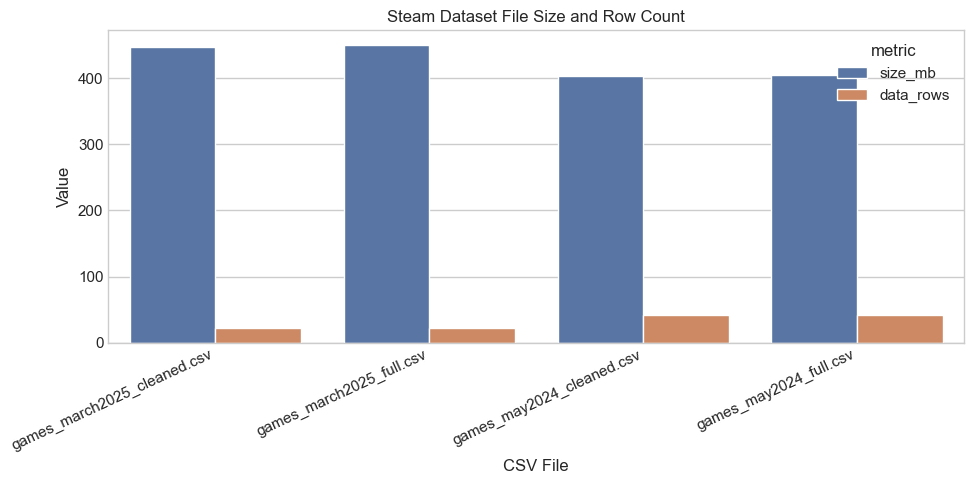

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/01_steam_dataset_file_size_and_rows.png


In [4]:
plt.figure(figsize=(10, 5))
plot_data = file_overview.melt(id_vars="file", value_vars=["size_mb", "data_rows"], var_name="metric", value_name="value")
sns.barplot(data=plot_data, x="file", y="value", hue="metric")
plt.title("Steam Dataset File Size and Row Count")
plt.xlabel("CSV File")
plt.ylabel("Value")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
figure_path = FIGURES_DIR / "01_steam_dataset_file_size_and_rows.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure:", figure_path)

## 4. 字段结构与版本差异

这个数据集包含 2024 年 5 月和 2025 年 3 月两个时间快照，并且每个时间点有 `cleaned` 和 `full` 两种版本。本节只读取表头，比较不同文件的字段数量和字段差异。

In [5]:
def read_header(path):
    with path.open("r", encoding="utf-8", errors="replace", newline="") as f:
        reader = csv.reader(f)
        return next(reader)

header_records = []
headers = {}
for filename in expected_files:
    header = read_header(RAW_DIR / filename)
    headers[filename] = header
    header_records.append({
        "file": filename,
        "column_count": len(header),
        "first_columns": ", ".join(header[:8]),
        "last_columns": ", ".join(header[-8:]),
    })

header_overview = pd.DataFrame(header_records)
display(header_overview)

all_columns = sorted(set().union(*[set(cols) for cols in headers.values()]))
column_presence = pd.DataFrame({"column": all_columns})
for filename, cols in headers.items():
    column_presence[filename] = column_presence["column"].isin(cols)

display(column_presence)

print("字段差异提示：")
for filename, cols in headers.items():
    missing_from_file = sorted(set(all_columns) - set(cols))
    print(filename, "missing columns:", missing_from_file)

,file,column_count,first_columns,last_columns
0,games_march2025_cleaned.csv,47,"appid, name, release_date, required_age, price...","median_playtime_2weeks, discount, peak_ccu, ta..."
1,games_march2025_full.csv,47,"appid, name, release_date, required_age, price...","median_playtime_2weeks, discount, peak_ccu, ta..."
2,games_may2024_cleaned.csv,46,"AppID, name, release_date, required_age, price...","median_playtime_forever, median_playtime_2week..."
3,games_may2024_full.csv,46,"AppID, name, release_date, required_age, price...","median_playtime_forever, median_playtime_2week..."


,column,games_march2025_cleaned.csv,games_march2025_full.csv,games_may2024_cleaned.csv,games_may2024_full.csv
0,AppID,False,False,True,True
1,about_the_game,True,True,True,True
2,achievements,True,True,True,True
3,appid,True,True,False,False
4,average_playtime_2weeks,True,True,True,True
5,average_playtime_forever,True,True,True,True
6,categories,True,True,True,True
7,detailed_description,True,True,True,True
8,developers,True,True,True,True
9,discount,True,True,False,False


字段差异提示：
games_march2025_cleaned.csv missing columns: ['AppID']
games_march2025_full.csv missing columns: ['AppID']
games_may2024_cleaned.csv missing columns: ['appid', 'discount']
games_may2024_full.csv missing columns: ['appid', 'discount']


字段比较说明：2024 文件中 `AppID` 使用大写开头，而 2025 文件中是 `appid`；2025 文件还多了 `discount` 字段。后续清洗 Notebook 需要统一字段名，尤其是 `AppID` 和 `appid`。

## 5. 样本读取与字段类型初判

为了避免直接把数百 MB 的文件全部读入内存，本节只读取主分析文件的少量样本。主分析文件暂定为 `games_march2025_cleaned.csv`，因为它是最新的 cleaned 快照，适合作为后续分析的主要版本。

In [6]:
MAIN_FILE = RAW_DIR / "games_march2025_cleaned.csv"
COMPARE_FILE = RAW_DIR / "games_may2024_cleaned.csv"

sample_df = pd.read_csv(MAIN_FILE, nrows=5)
print("Main analysis file:", MAIN_FILE.name)
print("Sample shape:", sample_df.shape)
display(sample_df)

sample_info = pd.DataFrame({
    "column": sample_df.columns,
    "sample_dtype": sample_df.dtypes.astype(str).values,
    "non_null_in_sample": sample_df.notna().sum().values,
})
display(sample_info)

Main analysis file: games_march2025_cleaned.csv
Sample shape: (5, 47)


,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,682,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608


,column,sample_dtype,non_null_in_sample
0,appid,int64,5
1,name,str,5
2,release_date,str,5
3,required_age,int64,5
4,price,float64,5
5,dlc_count,int64,5
6,detailed_description,str,5
7,about_the_game,str,5
8,short_description,str,5
9,reviews,str,1


样本读取可以快速观察字段内容，但不能代表完整数据的缺失率和分布。它主要用于确认列名、示例值和字段语义。完整的数据质量检查会放在后续清洗 Notebook 中完成。

## 6. 字段类型分组

根据字段语义，可以先把字段分成基础信息、平台字段、价格字段、玩家反馈字段、热度字段、游玩时长字段、多标签字段、文本字段和媒体链接字段。这个分组会帮助后续 Notebook 按主题分析。

In [7]:
field_groups = {
    "basic_info": ["appid", "name", "release_date", "required_age"],
    "platform": ["windows", "mac", "linux"],
    "price_package": ["price", "discount", "dlc_count", "packages"],
    "review_rating": ["positive", "negative", "user_score", "metacritic_score", "pct_pos_total", "num_reviews_total", "pct_pos_recent", "num_reviews_recent"],
    "popularity": ["recommendations", "peak_ccu"],
    "playtime": ["average_playtime_forever", "average_playtime_2weeks", "median_playtime_forever", "median_playtime_2weeks"],
    "multi_label": ["genres", "categories", "tags", "developers", "publishers", "supported_languages", "full_audio_languages"],
    "text": ["detailed_description", "about_the_game", "short_description", "reviews", "notes"],
    "media_link": ["header_image", "website", "support_url", "support_email", "metacritic_url", "screenshots", "movies"],
}

main_columns = headers[MAIN_FILE.name]
group_records = []
for group, cols in field_groups.items():
    for col in cols:
        group_records.append({
            "group": group,
            "column": col,
            "exists_in_main_file": col in main_columns,
        })
field_group_table = pd.DataFrame(group_records)
display(field_group_table)

coverage = field_group_table.groupby("group")["exists_in_main_file"].agg(["sum", "count"]).reset_index()
coverage["coverage_ratio"] = (coverage["sum"] / coverage["count"]).round(2)
display(coverage)

,group,column,exists_in_main_file
0,basic_info,appid,True
1,basic_info,name,True
2,basic_info,release_date,True
3,basic_info,required_age,True
4,platform,windows,True
5,platform,mac,True
6,platform,linux,True
7,price_package,price,True
8,price_package,discount,True
9,price_package,dlc_count,True


,group,sum,count,coverage_ratio
0,basic_info,4,4,1.0
1,media_link,7,7,1.0
2,multi_label,7,7,1.0
3,platform,3,3,1.0
4,playtime,4,4,1.0
5,popularity,2,2,1.0
6,price_package,4,4,1.0
7,review_rating,8,8,1.0
8,text,5,5,1.0


字段类型非常丰富，这是该数据集适合课程项目的重要原因：它不只是数值表，也包含多标签、文本、时间、平台和玩家反馈指标。后续分析可以围绕市场结构和玩家关注度建立更完整的叙事。

## 7. 轻量级选列读取检查

为了验证后续分析所需字段是否能顺利读取，本节只读取主分析文件中的一组核心字段。这个步骤比读取全部 47 列更稳健，也能体现大文件处理时“按需读取”的思想。

Core columns loaded: 17
Core dataframe shape: (89618, 17)


,appid,name,release_date,price,windows,mac,linux,recommendations,categories,genres,positive,negative,average_playtime_forever,peak_ccu,tags,pct_pos_total,num_reviews_total
0,730,Counter-Strike 2,2012-08-21,0.00,True,False,True,4401572,"['Multi-player', 'Cross-Platform Multiplayer',...","['Action', 'Free To Play']",7480813,1135108,33189,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0.00,True,False,False,1732007,"['Multi-player', 'PvP', 'Online PvP', 'Stats',...","['Action', 'Adventure', 'Massively Multiplayer...",1487960,1024436,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842
2,570,Dota 2,2013-07-09,0.00,True,True,True,14337,"['Multi-player', 'Co-op', 'Steam Trading Cards...","['Action', 'Strategy', 'Free To Play']",1998462,451338,43031,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595
3,271590,Grand Theft Auto V Legacy,2015-04-13,0.00,True,False,False,1803063,"['Single-player', 'Multi-player', 'PvP', 'Onli...","['Action', 'Adventure']",1719950,250012,19323,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,3.99,True,False,False,1165929,"['Single-player', 'Multi-player', 'PvP', 'Onli...",['Action'],1152763,218446,14204,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020


,column,missing_count,missing_ratio
0,appid,0,0.0
9,genres,0,0.0
15,pct_pos_total,0,0.0
14,tags,0,0.0
13,peak_ccu,0,0.0
12,average_playtime_forever,0,0.0
11,negative,0,0.0
10,positive,0,0.0
8,categories,0,0.0
1,name,0,0.0


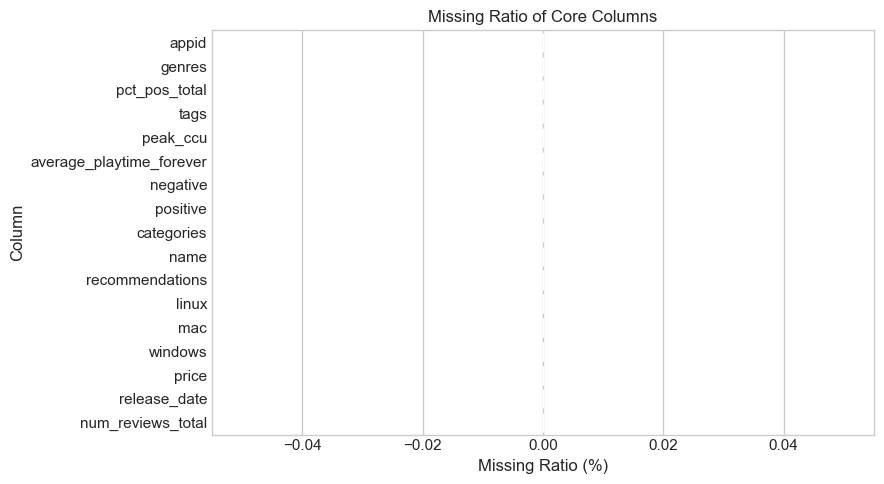

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/02_core_columns_missing_ratio.png


In [8]:
core_columns = [
    "appid", "name", "release_date", "price", "windows", "mac", "linux",
    "genres", "categories", "tags", "positive", "negative", "recommendations",
    "peak_ccu", "average_playtime_forever", "num_reviews_total", "pct_pos_total",
]
core_columns = [col for col in core_columns if col in main_columns]

core_df = pd.read_csv(MAIN_FILE, usecols=core_columns)
print("Core columns loaded:", len(core_columns))
print("Core dataframe shape:", core_df.shape)
display(core_df.head())

missing_core = pd.DataFrame({
    "column": core_df.columns,
    "missing_count": core_df.isna().sum().values,
    "missing_ratio": (core_df.isna().mean() * 100).round(2).values,
}).sort_values("missing_ratio", ascending=False)
display(missing_core)

plt.figure(figsize=(9, 5))
sns.barplot(data=missing_core, x="missing_ratio", y="column", color="#4C78A8")
plt.title("Missing Ratio of Core Columns")
plt.xlabel("Missing Ratio (%)")
plt.ylabel("Column")
plt.tight_layout()
figure_path = FIGURES_DIR / "02_core_columns_missing_ratio.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure:", figure_path)

轻量级选列读取表明，后续分析不需要一开始就加载所有长文本和媒体字段。对于大 CSV，先围绕研究问题选择必要列，是更合理的数据处理策略。

## 8. 主分析文件选择

本项目后续建议采用以下策略：

- `games_march2025_cleaned.csv`：作为主要分析文件，代表最新 Steam 数据快照。
- `games_may2024_cleaned.csv`：作为对比文件，用于观察 2024 到 2025 的变化。
- `full` 文件：保留为补充数据源，一般不作为默认分析入口。

这样既可以回答“当前 Steam 市场是什么样”，也可以回答“2024 到 2025 之间发生了什么变化”。

## 9. 本 Notebook 小结

通过本 Notebook 可以确认：Steam Games Dataset 2025 由 4 个大型 CSV 文件组成，总规模约 1.7GB，包含基础信息、价格、平台、评论、热度、游玩时长、多标签和长文本字段。它适合用于展示课程中的大规模表格数据处理、字段类型识别、后续清洗、特征工程和市场洞察分析。

下一步 Notebook 将比较 `pandas`、`duckdb` 和 `polars` 的实用处理策略，并决定后续主要采用怎样的读取和存储方式。